# 非评分实验：逻辑回归的梯度下降

在本实验中，你将实现逻辑回归的梯度下降更新步骤。

## 数据集
从之前使用的同一个数据集开始。

In [5]:
import numpy as np

X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1])

与之前一样，我们将使用辅助函数绘制这些数据。标签为 $y=1$ 的数据点显示为红色叉号，标签为 $y=0$ 的数据点显示为黑色圆圈。

Text(0.5, 0, '$x_1$')

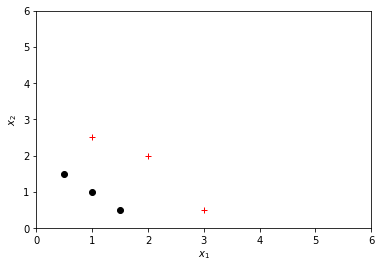

In [6]:
from lab_utils import plot_data
import matplotlib.pyplot as plt

plot_data(X,y)

# Set both axes to be from 0-6
plt.axis([0, 6, 0, 6])
# Set the y-axis label
plt.ylabel('$x_2$')
# Set the x-axis label
plt.xlabel('$x_1$')

## 梯度下降

 首先，你将实现梯度的非向量化版本。然后，你将实现其向量化版本。


### 非向量化版本

回顾一下，在梯度下降中，每次迭代都执行以下更新：

$$w_j :=w_j - \alpha \frac{\partial J(\mathbf{w})}{\partial w_j} \tag{1}$$ 

同时更新所有 $j$ 对应的 $w_j$，其中

$$ \frac{\partial J(\mathbf{w})}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 1}^{m} (f_{\mathbf{\mathbf{w}}}(\mathbf{x}^{(i)}) - y^{(i)})x_j^{(i)}\tag{2}$$ 

- **注意**：虽然这个梯度看起来与线性回归的梯度完全相同，但实际公式有所不同，因为线性回归与逻辑回归对 $f_w(x)$ 的定义不同。

你将在本实验中实现 $\frac{\partial J(\mathbf{w})}{\partial w_j}$。
* m 是数据集中的训练样本数

    
* $f_{\mathbf{w}}(x^{(i)})$ 是模型的预测值，而 $y^{(i)}$ 是实际标签

* 对于上述数据集的逻辑回归模型，可以表示为：

    $f_{\mathbf{w}}(x) = g(w_0 + w_1x_1 + w_2x_2)$

    其中，$g(z)$ 是 sigmoid 函数：

    $g(z) = \frac{1}{1+e^{-z}}$ 
    
    
* **预处理步骤**

   为便于实现，我们将在 $X$ 中添加一列全 1（作为 $x_0$），从而得到
    $f_{\mathbf{w}}(x) = g(w_0x_0 + w_1x_1 + w_2x_2)$
    
    这样，在计算模型预测值 $f_{\mathbf{w}}(x)$ 时，就可以编写一个 for 循环，在每一步计算 $w_jx_j$

In [7]:
# Add a column to X_orig to account for the w_0 term
X_mod = np.hstack([np.ones((X.shape[0],1)), X])

print(X_mod)

[[1.  0.5 1.5]
 [1.  1.  1. ]
 [1.  1.5 0.5]
 [1.  3.  0.5]
 [1.  2.  2. ]
 [1.  1.  2.5]]


#### 补充说明：sigmoid 函数的实现
我们已经为您实现了 `sigmoid` 函数，您只需像下面代码块所示那样导入并使用它即可。

In [8]:
from lab_utils import sigmoid 

print(sigmoid(0))

0.5


#### 实现

现在，你将实现非向量化版本的梯度。我们已经提供了一些起始代码，其功能如下：
* 创建一个与 $w$ 形状相同、用于保存梯度的数组（名为 `dw`），并将其初始化为零。我们将更新并返回 `dw`
* 使用一个 for 循环在每次迭代中计算 `dw[j]`
* 每次迭代时，可以使用上面的梯度公式，其中还包含另一个遍历数据集中所有样本的 for 循环
* 将每个样本的梯度值存入列表，然后用所有样本梯度之和除以样本数，计算梯度 `dw[j]`

假设该函数以列表/数组形式接收参数 $w$。

**练习**

你需要在内层 for 循环中实现以下步骤以完成代价函数：

* 首先，如下所示，为索引 $i$ 处的单个数据点计算模型预测 $f_\mathbf{w}(\mathbf{x}^{(i)})$

   ```
   z = 0
   for j in range(n):
       z += w[j] * X[i][j]
   f = sigmoid(z)
   ```
   
   由于 $w_0x_0 + w_1x_1+w_2x_2 = \mathbf{w}\cdot \mathbf{x}$，也可以按如下方式计算 $f_\mathbf{w}(\mathbf{x}^{(i)})$：
   ```
   z = np.dot(w, X[i])
   f = sigmoid(z)
   ```

* 然后，按如下方式计算索引 $i$ 处单个数据点的梯度：

  ```
  gradient = (f-y[i])*X[i][j] 
  ```

In [16]:
def compute_gradient(X, y, w):
    # Here X is assumed to pre-processed with a column of ones added as x_0
    m, n = X.shape
    dw = np.zeros_like(w)
    
    for j in range(n):
        gradient_list = []
        
        for i in range(m):        
            ### START CODE HERE ### 
            ### BEGIN SOLUTION ###  
            z = np.dot(w.T, X[i])
            f = sigmoid(z)
            gradient = (f-y[i])*X[i][j]          
            ### END SOLUTION ###  
            ### END CODE HERE ### 
            gradient_list.append(gradient)
        
        dw[j] = (1/m)* sum(gradient_list)
        
    return dw

使用下面的单元格检查梯度函数的实现。

In [17]:
w = np.zeros(3)
compute_gradient(X_mod,y,w)

array([ 0.        , -0.25      , -0.16666667])

**预期输出**

array([ 0.        , -0.25      , -0.16666667])

### （可选）向量化版本

现在，你将实现梯度函数的向量化版本。

梯度公式的向量化版本为

$$\frac{\partial \mathbf{J}(w_j)}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X^T}(\mathbf{f} - \mathbf{y})$$

其中

$$ \mathbf{f} = g(\mathbf{X}  \mathbf{w})$$

与之前一样，$g$ 是 sigmoid 函数


**练习**

你将通过实现以下步骤来补全向量化代价函数：

* 首先，按如下方式计算模型预测值 $f(x)$

   ```
   z = np.dot(X, w)
   f = sigmoid(z)
   ```
  

* 然后，按下式计算梯度

  ```
  dw = (1/m)*np.matmul(X.T, (f - y))
  ```

**调试提示：** 代码向量化有时并不容易。一种常用的调试策略是使用 size 函数打印正在处理的矩阵大小。例如，给定一个大小为 6×3（6 个样本、3 个特征）的数据矩阵 $\mathbf{X}$，以及维度为 3×1 的向量 $\mathbf{w}$，可以发现 $\mathbf{Xw}$ 是有效的乘法运算，而 $\mathbf{wX}$ 不是。

In [23]:
def compute_gradient_vectorized(X, y, w):
    
    m, n = X.shape
    
    ### START CODE HERE ### 
    ### BEGIN SOLUTION ###  
    f = sigmoid(np.matmul(X, w))
    dw = (1/m)*np.matmul(X.T, (f - y))
    ### END SOLUTION ###  
    ### START CODE HERE ### 
    return dw

现在检查该函数的输出是否与上面的非向量化实现的输出相同。

In [24]:
print("Cost computed by non-vectorized version: ", compute_gradient(X_mod, y, w))
print("Cost computed by vectorized version: ", compute_gradient_vectorized(X_mod, y, w))

Cost computed by non-vectorized version:  [ 0.         -0.25       -0.16666667]
Cost computed by vectorized version:  [ 0.         -0.25       -0.16666667]


**预期输出**

非向量化版本计算的代价：[ 0.         -0.25       -0.16666667]

向量化版本计算的代价：[ 0.         -0.25       -0.16666667]